# Model-Based RL: Learned World Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand model-based RL
- Learn world models from experience
- Use learned models for planning
- Compare model-based vs model-free

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of neural networks
- ✅ Python, NumPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Building model-based RL systems with learned world models

---

## Introduction

**Model-based RL** learns a model of the environment dynamics and uses it for planning, potentially achieving higher sample efficiency than model-free methods.

## Lesson Brief

This lesson introduces model-based RL, where the agent tries to learn how the environment works and then plan with that knowledge.

Students will see the full idea in simple form: collect experience, build a model, then use the model to choose actions.

Why this matters: model-based RL explains why some agents can learn faster from fewer environment interactions.

It also prepares students to think critically about model errors.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Yannic Kilcher - "Dreamer v2: Mastering Atari with Discrete World Models"**:
[Watch on YouTube](https://www.youtube.com/watch?v=o75ybZ-6Uu8)

Why this pick:
- strong paper-explainer style.
- Shows how world models support imagination-based learning and sample efficiency.
- Good match for students meeting model-based RL through modern world-model examples.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- World model: a learned model of environment behavior.
- Planning: reasoning before acting.
- Prediction error: model expectation versus reality.
- Imagined rollout: simulated future steps.
- Compounding error: small model mistakes that grow over many simulated steps.

### Quick Check
- What do we gain by learning a model?
- How can planning save real interaction?
- What risk comes from an inaccurate model?
- Why can long imagined rollouts become unreliable?

### Common Mistakes
- Thinking the model must be perfect.
- Ignoring accumulated model error.
- Confusing modeling the world with learning the policy.
- Assuming simulated planning is automatically trustworthy just because it is fast.


## Faster Learning Comes with a New Risk

Model-based RL is attractive because it can reuse experience more efficiently.
But the benefit comes with a new failure mode.

### The promise

If the agent learns a useful model of the world, it can plan in imagination instead of requiring every trial in the real environment.
That can greatly improve sample efficiency.

### The risk

If the model is wrong, planning can become confidently wrong too.
A small prediction error may not matter for one step, but over many imagined steps the error can accumulate.

### Teaching takeaway

Students should leave this notebook with both ideas together:

- model-based RL can learn faster
- model error can poison planning if we trust it too much

The point is not to worship sample efficiency alone.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- `gymnasium`'s `FrozenLake-v1` (4x4, **slippery**) — a standard benchmark whose *true* transition
  probabilities are published in `env.unwrapped.P`.
- Transitions collected by acting randomly in that real environment — no invented data anywhere.

**Outputs:** What you'll see when you run the cells

- A table and two figures showing, for four different data budgets: how far the learned model is
  from the true one, and how well a plan built from that learned model scores when it is actually
  run back in the environment.
- A printed row of the learned transition table next to the true one.

---

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries and open the real benchmark we will learn a model OF.
# WHY it matters: FrozenLake-v1 is one of the very few environments that hands you the TRUE
# transition probabilities (in env.unwrapped.P). That is a rare gift for teaching: we can learn
# a model from experience and then grade it against the exact answer, instead of just asserting
# that "the model got better".

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# is_slippery=True: each action succeeds only about 1/3 of the time and slides sideways
# otherwise. A stochastic environment is the honest case - a model must learn a probability
# DISTRIBUTION over next states, not a single next state.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n

print("Model-Based RL: Learned World Models")
print("=" * 60)
print("Environment:", env.spec.id, "| states:", N_STATES, "| actions:", N_ACTIONS)
print("\nThe loop we are about to run for real:")
print("  1. Collect  : act in the environment and record (s, a, r, s') transitions")
print("  2. Learn    : estimate P_hat(s'|s,a) and R_hat(s,a) by counting")
print("  3. Plan     : run value iteration INSIDE the learned model (zero new interactions)")
print("  4. Act      : run that plan back in the REAL environment and score it")
print("\nAnd because this environment publishes its true dynamics, we can also do")
print("something you normally cannot: measure how wrong the learned model still is.")

Model-Based RL: Learned World Models
Environment: FrozenLake-v1 | states: 16 | actions: 4

The loop we are about to run for real:
  1. Collect  : act in the environment and record (s, a, r, s') transitions
  2. Learn    : estimate P_hat(s'|s,a) and R_hat(s,a) by counting
  3. Plan     : run value iteration INSIDE the learned model (zero new interactions)
  4. Act      : run that plan back in the REAL environment and score it

And because this environment publishes its true dynamics, we can also do
something you normally cannot: measure how wrong the learned model still is.


## Worked Example: Learn a World Model From Real Experience, Then Plan With It

In model-based RL, the agent tries to answer this question:

`If I take action a in state s, what will probably happen next?`

Below, the agent explores the real `FrozenLake-v1` environment, counts the transitions it sees,
turns those counts into an estimated model `P_hat(s'|s,a)` and `R_hat(s,a)`, plans inside that
model with value iteration, and then runs the resulting plan back in the real environment.

This is the core loop of model-based RL: **experience -> model -> planning -> action**.

**What makes this lesson unusual:** FrozenLake publishes its true dynamics in `env.unwrapped.P`.
So we can grade the learned model against the exact answer, and grade the resulting plan against
the plan you would get if you already knew the environment perfectly. Both the promise (more data
-> better model -> better plan) and the risk (a model is only valid where you collected data) come
out as measured numbers rather than claims.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Terminal tiles (holes + goal), where an episode ends: [5, 7, 11, 12, 15]
Ceiling: planning with the TRUE model scores 0.732 on 500 real episodes.
(Not 1.0 - the ice is slippery, so even a perfect plan sometimes slides into a hole.)

  real steps | model error (all) | model error (visited states) | policy matches | success
  -----------|-------------------|------------------------------|----------------|--------
         500 |             0.724 |                        0.598 |           9/16 |   0.000
        2000 |             0.503 |                        0.278 |          14/16 |   0.634


       10000 |             0.410 |                        0.142 |          15/16 |   0.576


       50000 |             0.354 |                        0.060 |          16/16 |   0.732


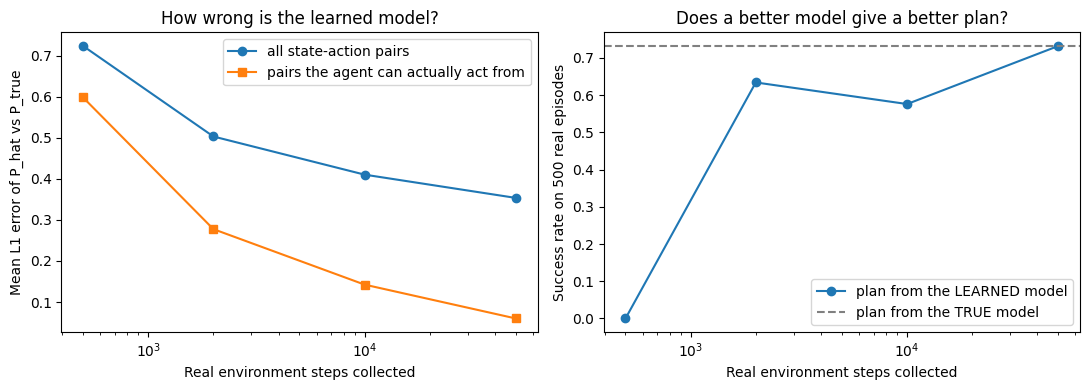


One concrete row of the model - P(s' | s=0, a=1 DOWN), after the largest budget:
  true    : {0: 0.333, 1: 0.333, 4: 0.333}
  learned : {0: 0.326, 1: 0.342, 4: 0.332}
  The agent was never told the ice slides. It counted, and the 1/3-1/3-1/3 fell out.

Reading the measured table:
- Model error on the states the agent can act from fell from 0.598
  to 0.060. More experience really does buy a better model.
- Success rate of the plan went from 0.000 to 0.732, against a
  ceiling of 0.732. Planning in a learned model is only as good as the model.
- But the trend is NOT monotonic: at 10000 steps the plan scored 0.576,
  BELOW the 0.634 it managed at 2000 steps - even though the model
  had got more accurate. A greedy plan is a discrete choice: one still-wrong action in
  one busy state can cost more than several small probability errors elsewhere. Model
  accuracy and policy quality are related, not the same number.
- The 'all pairs' error flattens near 0.354 and never reaches 0. That is N

In [2]:
# Worked example: collect real transitions, build a model by counting, plan inside it, and grade
# both the model AND the resulting policy against ground truth.
# WHY it matters: this makes "sample efficiency" and "model error" into numbers a student can
# read, instead of adjectives. Watch the model error fall and the policy quality rise together.

# --- Ground truth, straight out of Gymnasium -------------------------------------------------
# env.unwrapped.P[s][a] is a list of (probability, next_state, reward, terminated) tuples.
P_true = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R_true = np.zeros((N_STATES, N_ACTIONS))
terminal_states = set()
for s in range(N_STATES):
    for a in range(N_ACTIONS):
        for prob, s_next, reward, terminated in env.unwrapped.P[s][a]:
            P_true[s, a, s_next] += prob
            R_true[s, a] += prob * reward
            if terminated:
                terminal_states.add(s_next)
terminal_states = sorted(terminal_states)
non_terminal = [s for s in range(N_STATES) if s not in terminal_states]
print("Terminal tiles (holes + goal), where an episode ends:", terminal_states)


# --- Step 1: collect experience with a random policy -----------------------------------------
rng = np.random.default_rng(0)


def collect(n_steps):
    """Act uniformly at random for n_steps and count what happened. Returns raw counts."""
    counts = np.zeros((N_STATES, N_ACTIONS, N_STATES))
    reward_sum = np.zeros((N_STATES, N_ACTIONS))
    visits = np.zeros((N_STATES, N_ACTIONS))
    state, _ = env.reset(seed=0)
    for _ in range(n_steps):
        action = int(rng.integers(N_ACTIONS))
        next_state, reward, terminated, truncated, _ = env.step(action)
        counts[state, action, next_state] += 1
        reward_sum[state, action] += reward
        visits[state, action] += 1
        # An episode that ended must be restarted; the agent cannot keep acting from a hole.
        state = env.reset(seed=int(rng.integers(1_000_000)))[0] if (terminated or truncated) else next_state
    return counts, reward_sum, visits


# --- Step 2: turn counts into a model (this IS the "learning" - maximum likelihood) -----------
def build_model(counts, reward_sum, visits):
    """P_hat(s'|s,a) = (times we saw s->s' under a) / (times we tried a in s)."""
    totals = counts.sum(axis=2, keepdims=True)
    P_hat = counts / np.maximum(totals, 1)
    R_hat = reward_sum / np.maximum(visits, 1)
    return P_hat, R_hat


# --- Step 3: plan inside the model, with no further environment interaction ------------------
def value_iteration(P, R, gamma=0.99, tol=1e-10, max_sweeps=1000):
    """Classic value iteration on whatever model it is handed - true or learned."""
    V = np.zeros(N_STATES)
    for _ in range(max_sweeps):
        V_new = (R + gamma * (P @ V)).max(axis=1)
        if np.max(np.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new
    return (R + gamma * (P @ V)).argmax(axis=1)


# --- Step 4: score a plan by ACTING it in the real environment --------------------------------
def success_rate(policy, n_episodes=500, seed=10_000):
    """Fraction of fresh real episodes in which this policy reaches the goal."""
    wins = 0.0
    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i)
        for _ in range(100):
            state, reward, terminated, truncated, _ = env.step(int(policy[state]))
            if terminated or truncated:
                wins += reward
                break
    return wins / n_episodes


optimal_policy = value_iteration(P_true, R_true)
optimal_score = success_rate(optimal_policy)
print(f"Ceiling: planning with the TRUE model scores {optimal_score:.3f} on 500 real episodes.")
print("(Not 1.0 - the ice is slippery, so even a perfect plan sometimes slides into a hole.)\n")

budgets = [500, 2_000, 10_000, 50_000]
errors_all, errors_visited, scores = [], [], []
print("  real steps | model error (all) | model error (visited states) | policy matches | success")
print("  -----------|-------------------|------------------------------|----------------|--------")
for n in budgets:
    counts, reward_sum, visits = collect(n)
    P_hat, R_hat = build_model(counts, reward_sum, visits)
    # L1 distance per (state, action) between the learned and true distributions.
    err_all = np.abs(P_hat - P_true).sum(axis=2).mean()
    err_visited = np.abs(P_hat[non_terminal] - P_true[non_terminal]).sum(axis=2).mean()
    policy = value_iteration(P_hat, R_hat)
    agree = int((policy == optimal_policy).sum())
    score = success_rate(policy)
    errors_all.append(err_all); errors_visited.append(err_visited); scores.append(score)
    print(f"  {n:10d} | {err_all:17.3f} | {err_visited:28.3f} | {agree:11d}/{N_STATES} | {score:7.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(budgets, errors_all, marker="o", label="all state-action pairs")
axes[0].plot(budgets, errors_visited, marker="s", label="pairs the agent can actually act from")
axes[0].set_xscale("log"); axes[0].set_xlabel("Real environment steps collected")
axes[0].set_ylabel("Mean L1 error of P_hat vs P_true"); axes[0].legend()
axes[0].set_title("How wrong is the learned model?")
axes[1].plot(budgets, scores, marker="o", label="plan from the LEARNED model")
axes[1].axhline(optimal_score, linestyle="--", color="grey", label="plan from the TRUE model")
axes[1].set_xscale("log"); axes[1].set_xlabel("Real environment steps collected")
axes[1].set_ylabel("Success rate on 500 real episodes"); axes[1].legend()
axes[1].set_title("Does a better model give a better plan?")
plt.tight_layout(); plt.show()

print("\nOne concrete row of the model - P(s' | s=0, a=1 DOWN), after the largest budget:")
print("  true    :", {i: round(float(v), 3) for i, v in enumerate(P_true[0, 1]) if v > 0})
print("  learned :", {i: round(float(v), 3) for i, v in enumerate(P_hat[0, 1]) if v > 0.005})
print("  The agent was never told the ice slides. It counted, and the 1/3-1/3-1/3 fell out.")

print("\nReading the measured table:")
print(f"- Model error on the states the agent can act from fell from {errors_visited[0]:.3f}")
print(f"  to {errors_visited[-1]:.3f}. More experience really does buy a better model.")
print(f"- Success rate of the plan went from {scores[0]:.3f} to {scores[-1]:.3f}, against a")
print(f"  ceiling of {optimal_score:.3f}. Planning in a learned model is only as good as the model.")
# Honesty check: is the improvement actually monotonic? Say so either way.
dips = [i for i in range(1, len(scores)) if scores[i] < scores[i - 1]]
if dips:
    i = dips[0]
    print(f"- But the trend is NOT monotonic: at {budgets[i]} steps the plan scored {scores[i]:.3f},")
    print(f"  BELOW the {scores[i-1]:.3f} it managed at {budgets[i-1]} steps - even though the model")
    print("  had got more accurate. A greedy plan is a discrete choice: one still-wrong action in")
    print("  one busy state can cost more than several small probability errors elsewhere. Model")
    print("  accuracy and policy quality are related, not the same number.")
print(f"- The 'all pairs' error flattens near {errors_all[-1]:.3f} and never reaches 0. That is NOT")
print("  a bug: episodes END on the holes and the goal, so the agent never takes an action FROM")
print("  those tiles and can never learn their rows. A learned model is only valid where you")
print("  collected data - the single most important caveat in model-based RL.")

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. (1991). *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*. ACM SIGART Bulletin, 2(4), 160-163.
2. Ha, D. & Schmidhuber, J. (2018). *World Models*. arXiv:1803.10122. <https://arxiv.org/abs/1803.10122>
3. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
4. Hafner, D., Pasukonis, J., Ba, J. & Lillicrap, T. (2023). *Mastering Diverse Domains through World Models* (DreamerV3). arXiv:2301.04104. <https://arxiv.org/abs/2301.04104>
5. Moerland, T. M., Broekens, J., Plaat, A. & Jonker, C. M. (2020). *Model-based Reinforcement Learning: A Survey*. arXiv:2006.16712. <https://arxiv.org/abs/2006.16712>
"""))

## 📚 References

1. Sutton, R. S. (1991). *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*. ACM SIGART Bulletin, 2(4), 160-163.
2. Ha, D. & Schmidhuber, J. (2018). *World Models*. arXiv:1803.10122. <https://arxiv.org/abs/1803.10122>
3. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
4. Hafner, D., Pasukonis, J., Ba, J. & Lillicrap, T. (2023). *Mastering Diverse Domains through World Models* (DreamerV3). arXiv:2301.04104. <https://arxiv.org/abs/2301.04104>
5. Moerland, T. M., Broekens, J., Plaat, A. & Jonker, C. M. (2020). *Model-based Reinforcement Learning: A Survey*. arXiv:2006.16712. <https://arxiv.org/abs/2006.16712>


## Summary

This notebook ran the core loop of model-based RL for real:

- collect experience from a real Gymnasium environment
- learn an approximate transition and reward model by counting
- plan with that learned model using value iteration
- act on the plan in the real environment and score it

### Main takeaway

More experience produced a measurably more accurate model, and with the largest data budget the
learned model supported a plan that matched planning with the **true** dynamics — and after the
data is collected, planning costs **zero** further environment interactions.

Read the middle rows of the table carefully though: the success rate did **not** climb smoothly.
Model accuracy improved at every budget, but policy quality dipped once on the way. A plan is a
discrete choice of action per state, so a model that is "mostly better" can still be worse in the
one state that matters. Do not treat model error as a proxy for agent performance — measure both.

### Limitation to remember — and we measured this one too

The model error never reached zero. The residual is concentrated entirely on the holes and the
goal, because episodes *end* there and the agent therefore never takes an action from those tiles.

A learned model is only trustworthy **where you actually collected data**. Planning confidently in
the parts of the model you never visited is the classic way model-based RL fails.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


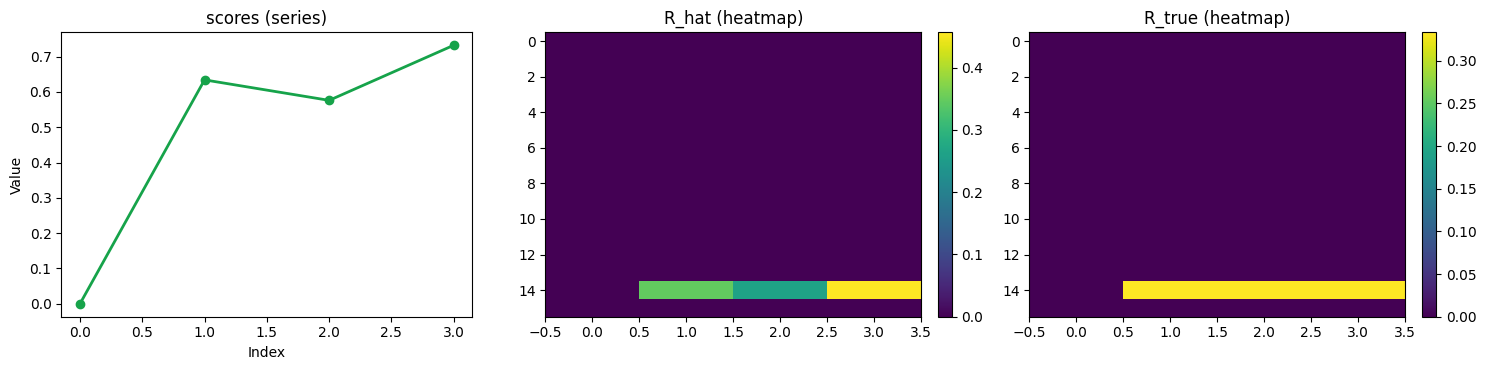

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Model-based RL learns or uses environment dynamics so the agent can simulate consequences before acting.

**If students remember one idea:** Planning becomes possible when the agent has a workable model of how actions change the world.

**Quick check before moving on:**
- Can you explain the difference between acting from experience only and acting with a learned model?
- Can you describe one advantage and one risk of relying on a world model?

**Bridge to the next step:** This makes it easier to compare model-based and model-free RL directly in the next lesson.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=8 | term=True | trunc=False


objc[66736]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101dc138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11071c9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66736]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101dc188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11071ca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66736]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101dbc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11071ca68). T

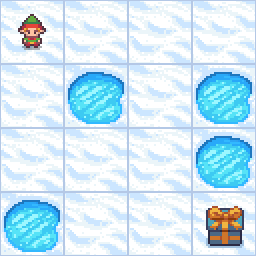

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
